# Traffic Demand Prediction using LightGBM & XGBoost


## 1. Setup & Environment Configurations

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import optuna

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 2. Data Loading

In [2]:
csv_path = 'Dataset/Metro_Interstate_Traffic_Volume.csv'
df = pd.read_csv(csv_path)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


## 3. Exploratory Data Analysis & Outlier Cleaning

In [3]:
print('Missing values in raw dataset:')
print(df.isnull().sum())

df['holiday'] = df['holiday'].fillna('None')

print('Minimum temperature in Kelvin:', df['temp'].min())
valid_temp_median = df.loc[df['temp'] > 0, 'temp'].median()
df.loc[df['temp'] <= 0, 'temp'] = valid_temp_median

print('Rain top 5 largest values:')
print(df['rain_1h'].nlargest(5))
df = df[df['rain_1h'] <= 100].copy()
print('Cleaned dataset shape:', df.shape)

Missing values in raw dataset:
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64
Minimum temperature in Kelvin: 0.0
Rain top 5 largest values:
24872    9831.30
8247       55.63
7179       44.45
25779      31.75
10806      28.70
Name: rain_1h, dtype: float64
Cleaned dataset shape: (48203, 9)


## 4. Date-Time Decomposition

In [4]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['Year'] = df['date_time'].dt.year
df['Month'] = df['date_time'].dt.month
df['Day'] = df['date_time'].dt.day
df['Hour'] = df['date_time'].dt.hour
df['DayOfWeek'] = df['date_time'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,Year,Month,Day,Hour,DayOfWeek,IsWeekend
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,2012,10,2,9,1,0
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,2012,10,2,10,1,0
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,2012,10,2,11,1,0
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,2012,10,2,12,1,0
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,2012,10,2,13,1,0


## 5. Train-Test Partitioning

In [5]:
X = df.drop(columns=['traffic_volume'])
y = df['traffic_volume']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Train size:', X_train.shape, 'Test size:', X_test.shape)

Train size: (38562, 14) Test size: (9641, 14)


## 6. Advanced Feature Engineering

In [6]:
group_cols = ['Hour', 'DayOfWeek']
train_density = pd.concat([X_train, y_train], axis=1).groupby(group_cols)['traffic_volume'].mean().reset_index()
train_density.rename(columns={'traffic_volume': 'traffic_density_score'}, inplace=True)
train_mean_fallback = y_train.mean()

def apply_density_score(data):
    res = data.copy()
    res = pd.merge(res, train_density, on=group_cols, how='left')
    res['traffic_density_score'] = res['traffic_density_score'].fillna(train_mean_fallback)
    return res

X_train = apply_density_score(X_train)
X_test = apply_density_score(X_test)

def add_engineered_features(data):
    df_feat = data.copy()
    df_feat['IsWeekend'] = (df_feat['DayOfWeek'] >= 5).astype(int)
    df_feat['IsPeakHour'] = ((df_feat['IsWeekend'] == 0) & df_feat['Hour'].isin([7, 16])).astype(int)
    df_feat['IsRushHour'] = ((df_feat['IsWeekend'] == 0) & df_feat['Hour'].isin([6, 7, 8, 15, 16, 17])).astype(int)
    
    df_feat['WeatherImpactScore'] = (df_feat['rain_1h'] * 2.0) + (df_feat['snow_1h'] * 10.0) + (df_feat['clouds_all'] / 100.0)
    df_feat.loc[df_feat['weather_main'].isin(['Squall', 'Thunderstorm', 'Snow']), 'WeatherImpactScore'] += 2.0
    df_feat.loc[df_feat['weather_main'].isin(['Rain', 'Drizzle', 'Mist', 'Fog', 'Smoke', 'Haze']), 'WeatherImpactScore'] += 1.0
    df_feat.loc[df_feat['weather_main'].isin(['Clouds']), 'WeatherImpactScore'] += 0.5
    return df_feat

X_train = add_engineered_features(X_train)
X_test = add_engineered_features(X_test)
X_train.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,Year,Month,Day,Hour,DayOfWeek,IsWeekend,traffic_density_score,IsPeakHour,IsRushHour,WeatherImpactScore
0,None,276.29,0.0,0.0,1,Clear,sky is clear,2017-03-21 01:00:00,2017,3,21,1,1,0,363.133333,0,0,0.01
1,None,278.84,0.0,0.0,90,Rain,moderate rain,2017-04-30 10:00:00,2017,4,30,10,6,1,3473.810345,0,0,1.90
2,None,292.58,9.0,0.0,8,Rain,heavy intensity rain,2016-08-11 03:00:00,2016,8,11,3,3,0,366.334764,0,0,19.08
3,None,290.76,0.0,0.0,0,Clear,Sky is Clear,2016-06-17 05:00:00,2016,6,17,5,4,0,2564.497942,0,0,0.00
4,None,287.51,0.0,0.0,90,Haze,haze,2018-05-22 03:00:00,2018,5,22,3,1,0,349.772908,0,0,1.90


## 7. Categorical Encoding & Alignment

In [7]:
cat_cols = ['holiday', 'weather_main', 'weather_description']
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

X_train_encoded.drop(columns=['date_time'], inplace=True)
X_test_encoded.drop(columns=['date_time'], inplace=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

dummy_cols = [c for c in X_train_encoded.columns if any(cat in c for cat in cat_cols)]
X_train_encoded[dummy_cols] = X_train_encoded[dummy_cols].astype(int)
X_test_encoded[dummy_cols] = X_test_encoded[dummy_cols].astype(int)
X_train_encoded.shape

(38562, 72)

## 8. Preprocessing Feature Scaling

In [8]:
num_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'WeatherImpactScore', 'traffic_density_score']
scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_encoded[num_cols])
print('Standardization completed.')

Standardization completed.


## 9. Model Development & Hyperparameter Tuning

In [9]:
print('Training Random Forest...')
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

print('Training LightGBM...')
lgb_reg = lgb.LGBMRegressor(learning_rate=0.08, num_leaves=89, max_depth=9, min_child_samples=22,
                            subsample=0.99, colsample_bytree=0.64, n_estimators=300, random_state=42, n_jobs=-1, verbose=-1)
lgb_reg.fit(X_train_scaled, y_train)

print('Training XGBoost...')
xgb_reg = xgb.XGBRegressor(learning_rate=0.06, max_depth=8, min_child_weight=2, subsample=0.95,
                           colsample_bytree=0.80, n_estimators=300, random_state=42, n_jobs=-1)
xgb_reg.fit(X_train_scaled, y_train)

class TrafficEnsembleRegressor:
    def __init__(self, lgb_model, xgb_model, lgb_weight=0.55, xgb_weight=0.45):
        self.lgb_model = lgb_model
        self.xgb_model = xgb_model
        self.lgb_weight = lgb_weight
        self.xgb_weight = xgb_weight
    def predict(self, X):
        return (self.lgb_weight * self.lgb_model.predict(X)) + (self.xgb_weight * self.xgb_model.predict(X))

ensemble = TrafficEnsembleRegressor(lgb_reg, xgb_reg, lgb_weight=0.55, xgb_weight=0.45)
print('All models trained successfully.')

Training Random Forest...


Training LightGBM...


Training XGBoost...


All models trained successfully.


## 10. Evaluation Comparison

In [10]:
models = {
    'Random Forest': rf,
    'XGBoost (Tuned)': xgb_reg,
    'LightGBM (Tuned)': lgb_reg,
    'Ensemble (55% LGB + 45% XGB)': ensemble
}

results_summary = []
for name, model in models.items():
    preds = model.predict(X_test_scaled)
    r2 = r2_score(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    
    results_summary.append({
        'Model': name,
        'R² Score': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

results_df = pd.DataFrame(results_summary)
results_df

,Model,R² Score,RMSE,MAE,MAPE
0,Random Forest,0.963712,377.872551,220.377023,0.887670
1,XGBoost (Tuned),0.978775,288.997467,176.209839,0.590306
2,LightGBM (Tuned),0.977955,294.525545,180.608764,0.543591
3,Ensemble (55% LGB + 45% XGB),0.978799,288.828808,175.874457,0.546554


## 11. Plot Visualizations

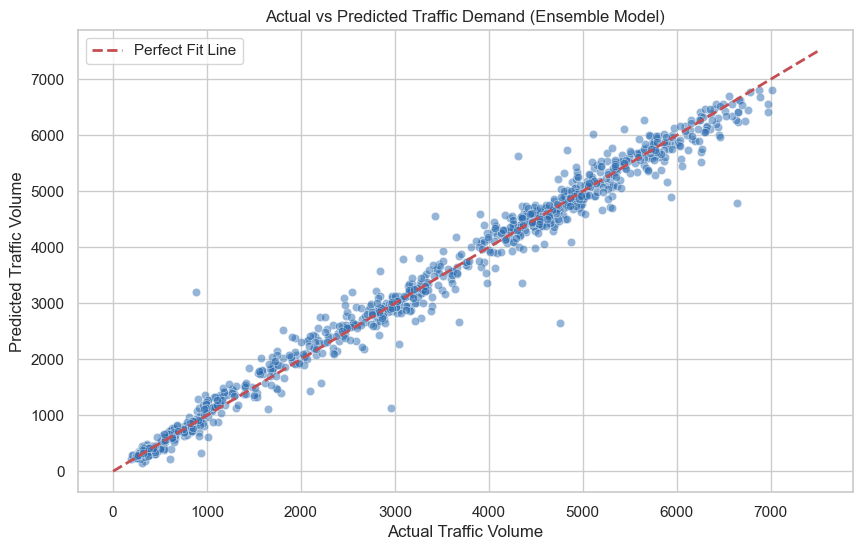

In [11]:
ens_preds = ensemble.predict(X_test_scaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test[:1000], y=ens_preds[:1000], alpha=0.5, color='#2B6CB0')
plt.plot([0, 7500], [0, 7500], 'r--', linewidth=2, label='Perfect Fit Line')
plt.title('Actual vs Predicted Traffic Demand (Ensemble Model)')
plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.legend()
plt.show()

C:\Users\itzjy\AppData\Local\Temp\ipykernel_5804\1412482208.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')


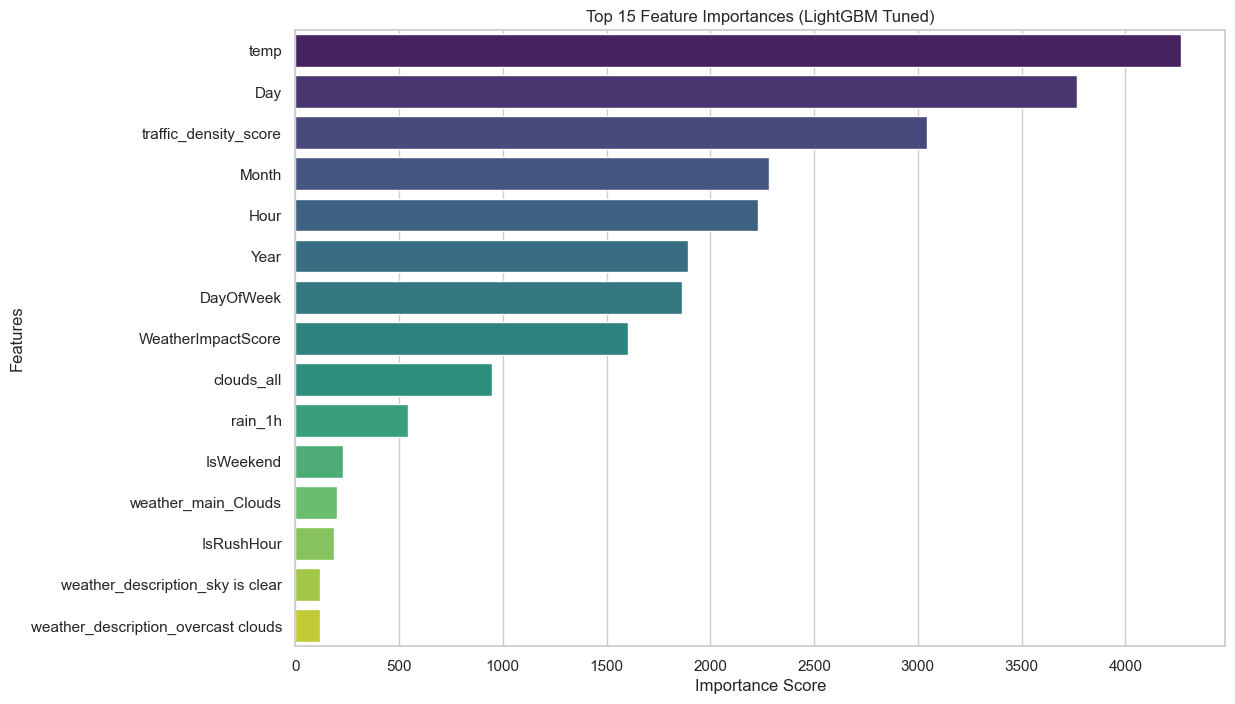

In [12]:
importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': lgb_reg.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (LightGBM Tuned)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()